# Úkol č. 1 - redukce dimenzionality a binární klasifikace

* Termíny jsou uvedeny na [courses.fit.cvut.cz/BI-ML2/homeworks/index.html](https://courses.fit.cvut.cz/BI-ML2/homeworks/index.html).
* Pokud odevzdáte úkol po prvním termínu ale před nejzazším termínem, budete penalizování -12 body, pozdější odevzdání je bez bodu.
* V rámci tohoto úkolu se musíte vypořádat s vysokou dimenzí problému a poté úspěšně aplikovat vhodný klasfikační model.
    
> **Úkoly jsou zadány tak, aby Vám daly prostor pro invenci. Vymyslet _jak přesně_ budete úkol řešit, je důležitou součástí zadání a originalita či nápaditost bude také hodnocena!**

Využívejte buňky typu `Markdown` k vysvětlování Vašeho postupu. Za nepřehlednost budou strhávány body.

## Zdroj dat

 * Zdrojem dat jsou soubory `train.csv` a `evaluate.csv`.
 * Jedná se o obrázky 28x28 pixelů ve stupních šedi, které byly získány z [Fashion Mnist datasetu](https://www.kaggle.com/datasets/zalando-research/fashionmnist).
 * Soubor `train.csv` obsahuje trénovací data.
 * Cílová (vysvětlovaná) proměnná se jmenuje **label**.
 * Soubor `evaluate.csv` obsahuje testovací data bez hodnot skutečných labelů.

## Pokyny k vypracování

**Body zadání**, za jejichž (poctivé) vypracování získáte **25 bodů**:
  * V notebooku načtěte data ze souboru `train.csv`. Vhodným způsobem si je rozdělte na podmnožiny, které Vám poslouží pro trénování, porovnávání modelů a následnou predikci výkonnosti finálního modelu.
  * Proveďte základní průzkum dat a svá pozorování diskutujte. Některé obrázky také zobrazte.
  * Postupně aplikujte modely **SVM**, **naivní Bayesův klasifikátor** a **LDA**, přičemž pro každý z nich:
      * Okomentujte vhodnost daného modelu pro daný typ úlohy.
      * Vyberte si hlavní hyperparametry k ladění (pokud model má hyperparametry) a najděte jejich nejlepší hodnoty.
      * U SVM vyzkoušejte alespoň dvě různé jádrové funkce.
      * Získané výsledky vždy řádně okomentujte.
<br/><br/>

  * Použijte natrénovaný generativní model Naivního Bayesova klasifikátoru nebo Lineární diskriminační analýzy (podle Vaší volby) a vygenerujte pro každou třídu 5 datových bodů, které následně přetransformujte do rozměrů 28x28 a zobrazte pomocí `imshow`. Diskutujte kvalitu vygenerovaných dat. K vygenerování můžete využít funkci [multivariate_normal](https://numpy.org/doc/2.2/reference/random/generated/numpy.random.multivariate_normal.html) z `numpy`.

  * Postupně aplikujte metody redukce dimenzionality PCA a LLE, přičemž pro každou z nich: 
      * Zopakujte předchozí kroky aplikace modelů (žádné další generování už nedělejte) a pokuste se je vylepšit.
      * Zkoumejte jaká dimenze je z hlediska výkonnosti finálního modelu nejlepší.
      * Získané výsledky vždy řádně okomentujte.
<br/><br/>
    
  * Ze všech zkoušených možností vyberte finální model a odhadněte, jakou přesnost můžete očekávat na nových datech, která jste doposud neměli k dispozici. _Pozor na metodické chyby!_
  
  * Nakonec načtěte vyhodnocovací data ze souboru`evaluate.csv`. Pomocí finálního modelu napočítejte predikce pro tyto data (vysvětlovaná proměnná v nich již není). Vytvořte soubor `results.csv`, ve kterém získané predikce uložíte do sloupce **label** a identifikátory do sloupce **ID**. Tento soubor též odevzdejte (uložte do projektu vedle notebooku).
   
       * Ukázka, jak by mělo vypadat prvních několik řádků souboru `results.csv` (obecně s jinými hodnotami):
  
```
ID,label
0,0
1,1
...
```

## Poznámky k odevzdání

  * Řiďte se pokyny ze stránky https://courses.fit.cvut.cz/BI-ML2/homeworks/index.html.
  * Vytvořte i csv soubor `results.csv` s predikcemi a uložte ho v rámci projektu vedle ipython notebooku.

In [1]:
### odtud už je to Vaše



# Řešení 🎯

In [2]:
# imports
import numpy as np
from numpy.random import multivariate_normal
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import LocallyLinearEmbedding as LLE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split, ParameterGrid, GridSearchCV

In [3]:
data = pd.read_csv('train.csv')

ydata = data['label']
Xdata = data.drop('label', axis=1)

seed = 42
# rozdělujeme data na trénovací, validační a testovací, poměr 60:20:20
Xtrain, Xtest, ytrain, ytest = train_test_split(Xdata, ydata, test_size=0.20, random_state=seed) 
Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, test_size=0.25, random_state=seed)

##  Průzkum dat 🧐

Vidíme, že dataset obsahuje dvě třídy dat, každá s přibližně 450 datovými body. Dat je poměrně málo, ale obě třídy jsou reprezentovány podobným množstvím vzorků.

In [4]:
num_classes = ytrain.nunique()
print(f"Počet unikátních tříd (label): {num_classes}")

label_counts = ytrain.value_counts().sort_index()
print("Počet obrázků pro každou třídu:")
print(label_counts)

Počet unikátních tříd (label): 2
Počet obrázků pro každou třídu:
label
0    443
1    457
Name: count, dtype: int64


Samotná data pak mají 784 atributů, což odpovídá, vzhledem k tomu, že se jedná o obrázky s 28x28 pixely. Hodnoty napříč všemi atributy se pak pohzbují mezi 0-255, jak by se dalo od černobílých obrázků rovněž očekávat. Histogramu výskytu různých hodnot pixelů vidíme, že obrázky obsahují hodně černé barvy, což je patrné i níže z pár vykreslených příkladů (černá je použita pro pozadí).

Dataset má 784 atributů.
Nejmenší hodnota: 0
Největší hodnota: 255


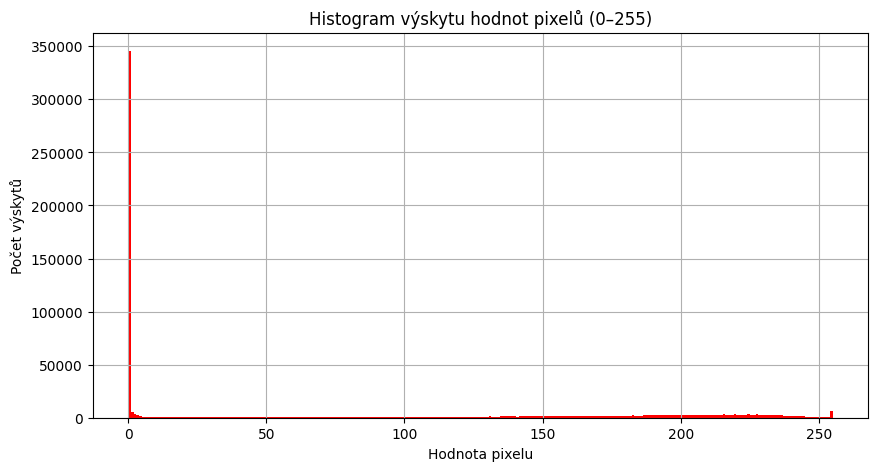

In [5]:
num_attributes = Xtrain.shape[1]
print(f"Dataset má {num_attributes} atributů.")

print(f"Nejmenší hodnota: {Xtrain.min().min()}")
print(f"Největší hodnota: {Xtrain.max().max()}")

pixel_values = Xtrain.values.flatten()

plt.figure(figsize=(10, 5))
plt.hist(pixel_values, bins=256, range=(0, 255), color='red', edgecolor=None)
plt.title("Histogram výskytu hodnot pixelů (0–255)")
plt.xlabel("Hodnota pixelu")
plt.ylabel("Počet výskytů")
plt.grid(True)
plt.show()

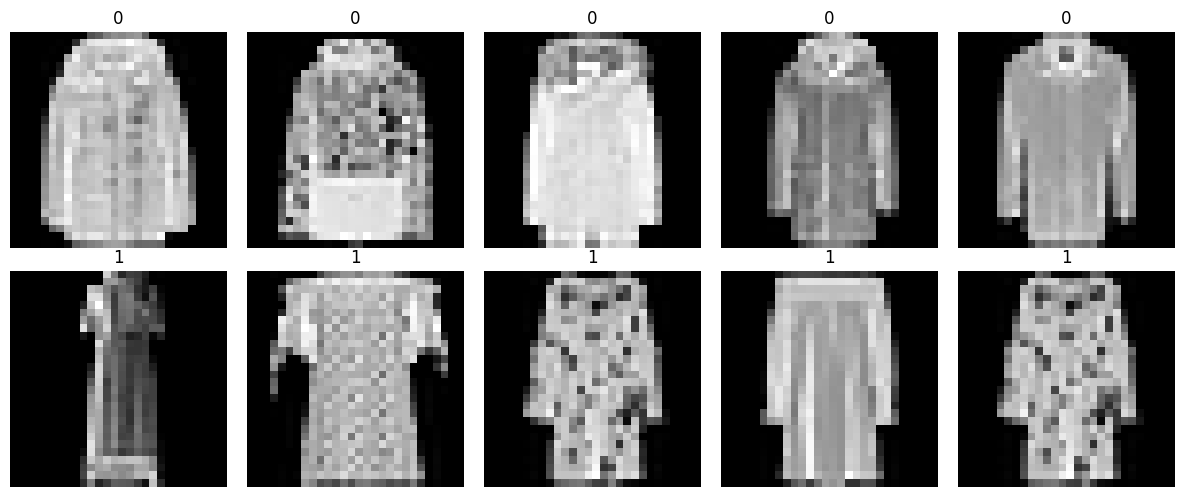

In [6]:
label_names = {0: "0", 1: "1"}

n = 10
plt.figure(figsize=(12, 5))

indices_0 = np.where(ytrain == 0)[0]
indices_1 = np.where(ytrain == 1)[0]

for i in range(n//2):
    idx = np.random.choice(indices_0)
    image = Xtrain.iloc[idx].values.reshape(28, 28)
    
    plt.subplot(2, n//2, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(label_names[0])
    plt.axis('off')

for i in range(n//2):
    idx = np.random.choice(indices_1)
    image = Xtrain.iloc[idx].values.reshape(28, 28)
    
    plt.subplot(2, n//2, i+1 + n//2)
    plt.imshow(image, cmap='gray')
    plt.title(label_names[1])
    plt.axis('off')

plt.tight_layout()
plt.show()

Z každé třídy jsme si zobrazily několik vzorků. Na základě těchto obrázků se zdá, že třída '0' obsahuje bundy a kabáty ('Coat' v původním Fashion MNIST datasetu) a třída '1' obsahuje šaty ('Dress').

## Modely 🤖🛠️

### SVM

SVM (Support Vector Machine) klasifikuje data nalezením optimální linie, která maximalizuje vzdálenost mezi každou třídou v N-rozměrném prostoru, a je obecně velmi silný pro menší a středně velké datasety, jako máme zde, s jasnými hranicemi mezi třídami. SVM je rovněž obzvlášť vhodný pro binární klasifikaci.

In [7]:
scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xval_scaled = scaler.transform(Xval)
Xtest_scaled = scaler.transform(Xtest)

model_accuracies = {}

Jako hypermetry pro ladění zvolíme jádro, penalizaci chyby a u nelineárního jádra ještě jeho koeficient.

In [8]:
param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 15, 20]},
    {'kernel': ['rbf'], 'C': [1, 10], 'gamma': [0.001, 0.01, 0.1, 0.2, 0.5]}
]

svm = SVC()
grid_search = GridSearchCV(svm, param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(Xtrain_scaled, ytrain)

print("Nejlepší parametry:", grid_search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Nejlepší parametry: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}


In [9]:
svm_model = grid_search.best_estimator_

ytrain_pred = svm_model.predict(Xtrain_scaled)
print(f"Přesnost na trénovací sadě: {accuracy_score(ytrain, ytrain_pred):.4f}")
print(confusion_matrix(ytrain, ytrain_pred))

yval_pred = svm_model.predict(Xval_scaled)
print(f"Přesnost na validační sadě: {accuracy_score(yval, yval_pred):.4f}")
print(confusion_matrix(yval, yval_pred))

model_accuracies['svm_model'] = accuracy_score(yval, yval_pred)

Přesnost na trénovací sadě: 0.9978
[[443   0]
 [  2 455]]
Přesnost na validační sadě: 0.9333
[[133  10]
 [ 10 147]]


Pro ohodnocení kvality modelu zvolíme jako hlavní míru přesnost (accuracy - podíl správně klasifikovaných dat versus všech dat). Zde můžeme vidět, že model má velmi vysokou přesnost na trénovacích datech a může tedy hrozit, že je přeučený.

Dále se také podíváme na matici záměn modelu. Data ve validační množině mají podobně zastoupeny obě dvě třídy, přičemž třída '1' má o několik datových bodů více, stejně jako tomu bylo u trénovací množiny. Nezdá se však, že by model měl tendenci jednu ze tříd nesprávně více identifikovat.

### Naivní Bayesův klasifikátor

Naivní Bayes je jednoduchý a rychlý model (co se týče učení i predikce), ale pro obrázky oblečení, které máme zde může být značně nevhodný, protože na vstupu předpokládá nezávislost atributů, což u obrázků zpravidla neplatí, a nedokáže pracovat s prostorovou strukturou ('neví, že dva sousední pixely spolu souvisí').

U tohoto modelu nejsou žádné hyperparametry, které by bylo vhodné ladit.

In [10]:
# zadne parametry nezkousime
nb_model = GaussianNB()
nb_model.fit(Xtrain, ytrain)

ytrain_pred = nb_model.predict(Xtrain)
yval_pred = nb_model.predict(Xval)

ytrain_pred = nb_model.predict(Xtrain)
print(f"Přesnost na trénovací sadě: {accuracy_score(ytrain, ytrain_pred):.4f}")
print(confusion_matrix(ytrain, ytrain_pred))

yval_pred = nb_model.predict(Xval)
print(f"Přesnost na validační sadě: {accuracy_score(yval, yval_pred):.4f}")
print(confusion_matrix(yval, yval_pred))

model_accuracies['nb_model'] = accuracy_score(yval, yval_pred)

Přesnost na trénovací sadě: 0.8789
[[346  97]
 [ 12 445]]
Přesnost na validační sadě: 0.8533
[[103  40]
 [  4 153]]


Jak můžeme vidět na výsledcích, tento model si vede značně hůře, než ten předchozí. Rovněž se zdá, že má tendenci nesprávně identifikovat třídu '0' jako třídu '1' (kabáty identifikuje častěji jako šaty).

### LDA

LDA je vhodný pro binární klasifikaci, protoře optimalizuje separaci mezi dvěma třídami (má za cíl najít přímku, která co nejlépe odděluje dvě třídy), ale předpokládá, že data mají gaussovské rozdělení a stejnou kovarianční matici. U obrázků funguje lépe, když jsou rozumně zredukované, což vyzkoušíme později.

I zde vyzkoušíme ladění pár hyperparametrů.

In [11]:
param_grid = {
    'solver': ['svd', 'lsqr', 'eigen'],
    'shrinkage': [None, 'auto']
}

valid_params = []
for params in ParameterGrid(param_grid):
    if params['solver'] == 'svd' and params['shrinkage'] is not None: # svd nemá parametr shrinkage
        continue
    valid_params.append(params)

best_score = 0
best_params = None

for params in valid_params:
    try:
        lda = LDA(**params)
        lda.fit(Xtrain_scaled, ytrain)
        score = lda.score(Xval_scaled, yval)
        if score > best_score:
            best_score = score
            best_params = params
    except Exception:
        pass

print("Nejlepší parametry:", best_params)

Nejlepší parametry: {'shrinkage': 'auto', 'solver': 'lsqr'}


In [12]:
lda_model = LDA(**best_params)
lda_model.fit(Xtrain_scaled, ytrain)

ytrain_pred = lda_model.predict(Xtrain_scaled)
print(f"Přesnost na trénovací sadě: {accuracy_score(ytrain, ytrain_pred):.4f}")
print(confusion_matrix(ytrain, ytrain_pred))

yval_pred = lda_model.predict(Xval_scaled)
print(f"Přesnost na validační sadě: {accuracy_score(yval, yval_pred):.4f}")
print(confusion_matrix(yval, yval_pred))

model_accuracies['lda_model'] = accuracy_score(yval, yval_pred)

Přesnost na trénovací sadě: 0.9856
[[439   4]
 [  9 448]]
Přesnost na validační sadě: 0.9267
[[130  13]
 [  9 148]]


Zde už vidíme lepší přesnost podobnou prvnímu modelu. I zde je ale přesnost na trénovacích datech poměrně vysoká. Matice záměn neukazuje, že by model tíhl více k jedné ze tříd.

## Generovaní datových bodů 🖼️✍

Podle zadání si vygenerujeme pár ukázkových datových bodů pro každou ze tříd. Použijeme k tomu model LDA, jelikož si při klasifikaci vedl o dost lépe.

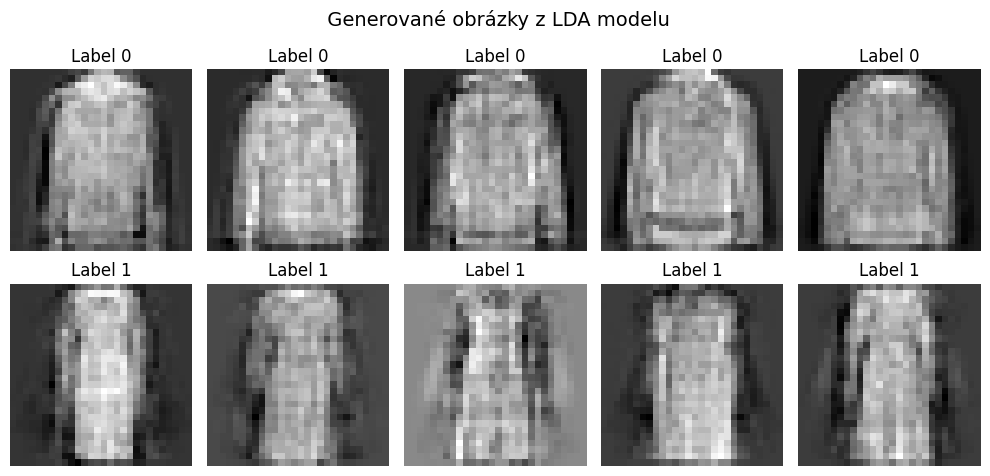

In [13]:
X_all = np.vstack([Xtrain, Xval])
y_all = np.concatenate([ytrain, yval])

class_params = {}
for label in np.unique(y_all):
    class_data = X_all[y_all == label]
    mean = class_data.mean(axis=0)
    cov = np.cov(class_data.T) + 1e-5 * np.eye(class_data.shape[1])
    class_params[label] = (mean, cov)

fig, axs = plt.subplots(nrows=2, ncols=5, figsize=(10, 5))
fig.suptitle(" Generované obrázky z LDA modelu", fontsize=14)

for i, label in enumerate(sorted(class_params.keys())):
    mean, cov = class_params[label]
    samples = multivariate_normal(mean, cov, size=5)

    for j in range(5):
        ax = axs[i, j]
        ax.imshow(samples[j].reshape(28, 28), cmap='gray')
        ax.axis('off')
        ax.set_title(f"Label {label}")

plt.tight_layout()
plt.show()

Výsledky jsou oproti původním datům dost nejasné, ale mají rozlišitelné obrysy, z nichž by se dalo vyčíst, zda se jedná o bundu nebo šaty. Model má taky problém dát do pozadí čistě černou barvu, jak tomu bylo jasně dané v původních datech.

## PCA ✂️

Nyní na každém z modelu vyzkoušíme dva způsoby redukce dimenze dat, přičemž budeme zároveň hledat nejlepší hyperparametry modelů a nejlepší počet komponent PCA/LLE.

#### SVM

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Nejlepší parametry pro PCA 5: {'svc__C': 10, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}, přesnost: 0.9289

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Nejlepší parametry pro PCA 10: {'svc__C': 10, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}, přesnost: 0.9489

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Nejlepší parametry pro PCA 15: {'svc__C': 0.1, 'svc__kernel': 'linear'}, přesnost: 0.9456

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Nejlepší parametry pro PCA 20: {'svc__C': 0.1, 'svc__kernel': 'linear'}, přesnost: 0.9478

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Nejlepší parametry pro PCA 30: {'svc__C': 0.1, 'svc__kernel': 'linear'}, přesnost: 0.9522

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Nejlepší parametry pro PCA 50: {'svc__C': 0.1, 'svc__kernel': 'linear'}, přesnost: 0.9467

Fitting 3 folds for each of 10 candidates, totalling 30

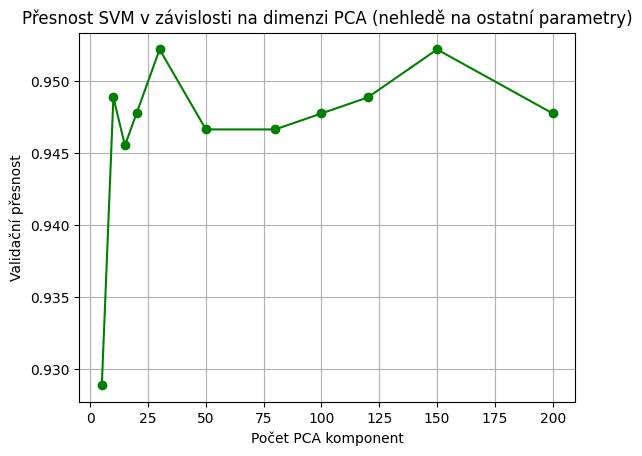


Celkově nejlepší kombinace:
PCA n_components = 30
Parametry = {'svc__C': 0.1, 'svc__kernel': 'linear'}


In [14]:
pca_components = [5, 10, 15, 20, 30, 50, 80, 100, 120, 150, 200]
param_grid = [
    {'svc__kernel': ['linear'], 'svc__C': [0.1, 1, 10, 15]},
    {'svc__kernel': ['rbf'], 'svc__C': [1, 10], 'svc__gamma': [0.001, 0.01, 0.1]}
]

best_score = 0
best_params = None
best_n_components = None
svm_scores = []

for n in pca_components:
    pca = PCA(n_components=n, random_state=seed)
    
    pipeline = Pipeline([
        ('pca', pca),
        ('svc', SVC())
    ])
    
    grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)
    grid_search.fit(Xtrain_scaled, ytrain)

    svm_scores.append(grid_search.best_score_)
    
    print(f"Nejlepší parametry pro PCA {n}: {grid_search.best_params_}, přesnost: {grid_search.best_score_:.4f}\n")
    
    if grid_search.best_score_ > best_score:
        best_score = grid_search.best_score_
        best_params = grid_search.best_params_
        best_n_components = n

plt.plot(pca_components, svm_scores, marker='o', color='green')
plt.xlabel("Počet PCA komponent")
plt.ylabel("Validační přesnost")
plt.title("Přesnost SVM v závislosti na dimenzi PCA (nehledě na ostatní parametry)")
plt.grid(True)
plt.show()

print("\nCelkově nejlepší kombinace:")
print(f"PCA n_components = {best_n_components}")
print(f"Parametry = {best_params}")

Kromě nejmenšího počtu komponent (5), si model vede podobně nehledě na počet komponent, s přesností v rozmezí 0.945-0.955. Nejlépe se mu vede pro počet komponent 30 (s lineárním jádrem) a 150 (s nelineárním jádrem).

In [15]:
svm_pca_model = Pipeline([
    ('pca', PCA(n_components=best_n_components, random_state=seed)),
    ('svc', SVC(
        kernel=best_params['svc__kernel'],
        C=best_params['svc__C'],
        gamma=best_params.get('svc__gamma', 'auto')
    ))
])

svm_pca_model.fit(Xtrain_scaled, ytrain)

ytrain_pred = svm_pca_model.predict(Xtrain_scaled)
print(f"Přesnost na trénovací sadě: {accuracy_score(ytrain, ytrain_pred):.4f}")
print(confusion_matrix(ytrain, ytrain_pred))

yval_pred = svm_pca_model.predict(Xval_scaled)
print(f"Přesnost na validační sadě: {accuracy_score(yval, yval_pred):.4f}")
print(confusion_matrix(yval, yval_pred))

model_accuracies['svm_pca_model'] = accuracy_score(yval, yval_pred)

Přesnost na trénovací sadě: 0.9656
[[430  13]
 [ 18 439]]
Přesnost na validační sadě: 0.9600
[[137   6]
 [  6 151]]


Zde už vidíme, že přesnost na trénovacích datech o něco klesla v porovnání s neredukovaných modelem, za to si ale vede lépe na validačních datech. Matice záměň opět ukazuje, že model neupřednostňuje ani jednu ze tříd.

#### Naivní Bayesův klasifikátor

U Bayese opět neladíme žádné parametry a zaměřujeme se tedy pouze na počet dimenzí po PCA.

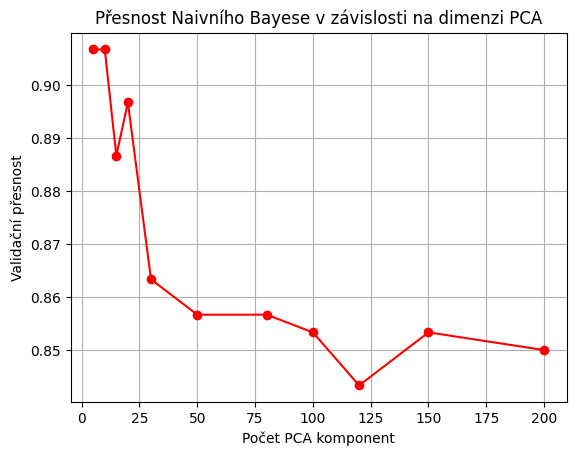


 Nejlepší počet komponent: 5


In [16]:
best_score = 0
best_n_components = None
nb_scores = []

for n in pca_components:

    pca = PCA(n_components=n, random_state=seed)
    
    pipeline = Pipeline([
        ('pca', pca),
        ('nb', GaussianNB())
    ])
    
    pipeline.fit(Xtrain_scaled, ytrain)
    yval_pred = pipeline.predict(Xval_scaled)
    acc = accuracy_score(yval, yval_pred)
    nb_scores.append(acc)
    
    if acc > best_score:
        best_score = acc
        best_n_components = n

plt.plot(pca_components, nb_scores, marker='o', color='red')
plt.xlabel("Počet PCA komponent")
plt.ylabel("Validační přesnost")
plt.title("Přesnost Naivního Bayese v závislosti na dimenzi PCA")
plt.grid(True)
plt.show()

print("\n Nejlepší počet komponent:", best_n_components)

Tento model si vede lépe s menším počtem dimenzí a jeho přesnost znatelně klesá čím vyšší výsledný počet dimenzí.

In [17]:
nb_pca_model = Pipeline([
    ('pca', PCA(n_components=best_n_components, random_state=seed)),
    ('nb', GaussianNB())
])

nb_pca_model.fit(Xtrain_scaled, ytrain)

ytrain_pred = nb_pca_model.predict(Xtrain_scaled)
print(f"Přesnost na trénovací sadě: {accuracy_score(ytrain, ytrain_pred):.4f}")
print(confusion_matrix(ytrain, ytrain_pred))

yval_pred = nb_pca_model.predict(Xval_scaled)
print(f"Přesnost na validační sadě: {accuracy_score(yval, yval_pred):.4f}")
print(confusion_matrix(yval, yval_pred))

model_accuracies['nb_pca_model'] = accuracy_score(yval, yval_pred)

Přesnost na trénovací sadě: 0.9089
[[375  68]
 [ 14 443]]
Přesnost na validační sadě: 0.9067
[[116  27]
 [  1 156]]


Celkové výsledky jsou také o dost lepší než bez redukce dimenzionality. Opět je ale patrné, že model má problém klasifikovat správně jednu ze tříd.

#### LDA

U LDA budeme opět zároveň s nejlepším počtem komponent zkoumat i nejlepší kombinaci hyperparametrů.

Nejlepší parametry pro PCA 5: {'shrinkage': None, 'solver': 'svd'}, přesnost: 0.9100

Nejlepší parametry pro PCA 10: {'shrinkage': None, 'solver': 'svd'}, přesnost: 0.9300

Nejlepší parametry pro PCA 15: {'shrinkage': None, 'solver': 'svd'}, přesnost: 0.9422

Nejlepší parametry pro PCA 20: {'shrinkage': None, 'solver': 'svd'}, přesnost: 0.9456

Nejlepší parametry pro PCA 30: {'shrinkage': None, 'solver': 'svd'}, přesnost: 0.9444

Nejlepší parametry pro PCA 50: {'shrinkage': None, 'solver': 'svd'}, přesnost: 0.9467

Nejlepší parametry pro PCA 80: {'shrinkage': None, 'solver': 'svd'}, přesnost: 0.9389

Nejlepší parametry pro PCA 100: {'shrinkage': None, 'solver': 'svd'}, přesnost: 0.9411

Nejlepší parametry pro PCA 120: {'shrinkage': None, 'solver': 'svd'}, přesnost: 0.9367

Nejlepší parametry pro PCA 150: {'shrinkage': None, 'solver': 'svd'}, přesnost: 0.9300

Nejlepší parametry pro PCA 200: {'shrinkage': None, 'solver': 'svd'}, přesnost: 0.9278



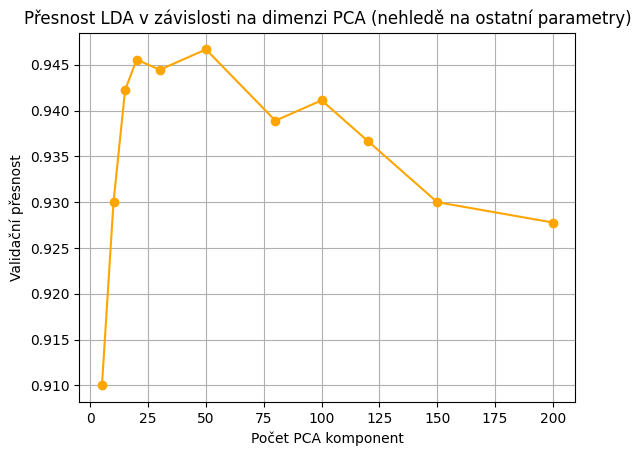


Celkově nejlepší kombinace:
PCA n_components = 50
LDA parametry = {'shrinkage': None, 'solver': 'svd'}


In [18]:
param_grid = {
    'solver': ['svd', 'lsqr', 'eigen'],
    'shrinkage': [None, 'auto']
}

valid_params = []
for params in ParameterGrid(param_grid):
    if params['solver'] == 'svd' and params['shrinkage'] is not None:
        continue
    valid_params.append(params)

best_score = 0
best_params = None
best_n_components = None
lda_scores = []

for n in pca_components:
    pca = PCA(n_components=n, random_state=seed)
    
    best_score_for_n = 0
    best_params_for_n = None

    for params in valid_params:
        try:
            lda = LDA(**params)
            
            pipeline = Pipeline([
                ('pca', pca),
                ('lda', lda)
            ])
            
            scores = cross_val_score(pipeline, Xtrain_scaled, ytrain, cv=3, scoring='accuracy', n_jobs=-1)
            mean_score = scores.mean()
            
            if mean_score > best_score_for_n:
                best_score_for_n = mean_score
                best_params_for_n = params

            if mean_score > best_score:
                best_score = mean_score
                best_params = params
                best_n_components = n

        except Exception:
            pass

    lda_scores.append(best_score_for_n)

    print(f"Nejlepší parametry pro PCA {n}: {best_params_for_n}, přesnost: {best_score_for_n:.4f}\n")

plt.plot(pca_components, lda_scores, marker='o', color='orange')
plt.xlabel("Počet PCA komponent")
plt.ylabel("Validační přesnost")
plt.title("Přesnost LDA v závislosti na dimenzi PCA (nehledě na ostatní parametry)")
plt.grid(True)
plt.show()

print("\nCelkově nejlepší kombinace:")
print(f"PCA n_components = {best_n_components}")
print(f"LDA parametry = {best_params}")

Zdá se, že LDA s PCA preferuje stejnou sadu hyperparametrů nehledě na počet dimenzí. Počet preferovaných komponent se pohybuje mezi 20 a 50.

In [19]:
lda_pca_model = Pipeline([
    ('pca', PCA(n_components=best_n_components, random_state=seed)),
    ('lda', LDA(
        solver=best_params['solver'],
        shrinkage=best_params['shrinkage']
    ))
])

lda_pca_model.fit(Xtrain_scaled, ytrain)

ytrain_pred = lda_pca_model.predict(Xtrain_scaled)
print(f"Přesnost na trénovací sadě: {accuracy_score(ytrain, ytrain_pred):.4f}")
print(confusion_matrix(ytrain, ytrain_pred))

yval_pred = lda_pca_model.predict(Xval_scaled)
print(f"Přesnost na validační sadě: {accuracy_score(yval, yval_pred):.4f}")
print(confusion_matrix(yval, yval_pred))

model_accuracies['lda_pca_model'] = accuracy_score(yval, yval_pred)

Přesnost na trénovací sadě: 0.9533
[[422  21]
 [ 21 436]]
Přesnost na validační sadě: 0.9400
[[132  11]
 [  7 150]]


Na výsledcích můžeme pozorovat podobný trend jako u SVM s PCA, kde se snížila přesnost na trénovací množině, ale zvýšila se u validační množiny. Matice záměň se rovněž strukturálně neliší.

## LLE ⬇️

Druhou metodu redukce dimenzionality, kterou s modely vyzkoušíme je LLE. Vedle původních hyperparamterů modelů a počet komponent LLE zde budeme ještě zkoumat optimální počet sousedů v LLE.

#### SVM

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Nejlepší parametry pro LLE 10: {'lle__n_neighbors': 10, 'svc__C': 15, 'svc__kernel': 'linear'}, přesnost: 0.9156

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Nejlepší parametry pro LLE 20: {'lle__n_neighbors': 15, 'svc__C': 15, 'svc__kernel': 'linear'}, přesnost: 0.9411

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Nejlepší parametry pro LLE 30: {'lle__n_neighbors': 20, 'svc__C': 10, 'svc__kernel': 'linear'}, přesnost: 0.9444

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Nejlepší parametry pro LLE 50: {'lle__n_neighbors': 15, 'svc__C': 15, 'svc__kernel': 'linear'}, přesnost: 0.9456

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Nejlepší parametry pro LLE 80: {'lle__n_neighbors': 20, 'svc__C': 1, 'svc__kernel': 'linear'}, přesnost: 0.9500

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Nejlepší parametry pro LLE 100: {'lle__n_neighbors': 20, 's

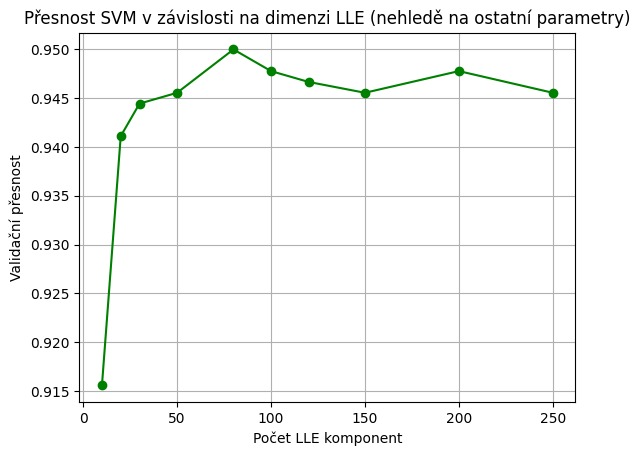


Celkově nejlepší kombinace:
LLE počet komponent = 80
LLE počet sousedů a SVM parametry = {'lle__n_neighbors': 20, 'svc__C': 1, 'svc__kernel': 'linear'}


In [20]:
lle_dims = [10, 20, 30, 50, 80, 100, 120, 150, 200, 250]
neighbors = [5, 10, 15, 20]
param_grid = [
    {'lle__n_neighbors': neighbors, 'svc__kernel': ['linear'], 'svc__C': [0.1, 1, 10, 15]},
    {'lle__n_neighbors': neighbors, 'svc__kernel': ['rbf'], 'svc__C': [1, 10], 'svc__gamma': [0.001, 0.01, 0.1]}
]

best_score = 0
best_params = None
best_n_components = None
lle_scores = []

for n in lle_dims:
    lle = LLE(n_components=n, random_state=seed)
    
    pipeline = Pipeline([
        ('lle', lle),
        ('svc', SVC())
    ])

    grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)
    grid_search.fit(Xtrain_scaled, ytrain)

    lle_scores.append(grid_search.best_score_)

    print(f"Nejlepší parametry pro LLE {n}: {grid_search.best_params_}, přesnost: {grid_search.best_score_:.4f}\n")
    
    if grid_search.best_score_ > best_score:
        best_score = grid_search.best_score_
        best_params = grid_search.best_params_
        best_n_components = n

plt.plot(lle_dims, lle_scores, marker='o', color='green')
plt.xlabel("Počet LLE komponent")
plt.ylabel("Validační přesnost")
plt.title("Přesnost SVM v závislosti na dimenzi LLE (nehledě na ostatní parametry)")
plt.grid(True)
plt.show()

print("\nCelkově nejlepší kombinace:")
print(f"LLE počet komponent = {best_n_components}")
print(f"LLE počet sousedů a SVM parametry = {best_params}")

Graf přesnosti v závislosti na dimenzi vypádá podobně jako u SVM s PCA, ale skoky v hodnotách jsou tu mírnější. Hodnoty se jinak pohybují v podobných mezích. Obecně se zdá, že ale SVM s LLE častěji preferuje lineární jádro.

In [21]:
svm_lle_model = Pipeline([
    ('lle', LLE(n_components=best_n_components, n_neighbors=best_params['lle__n_neighbors'], random_state=seed)),
    ('svc', SVC(
        kernel=best_params['svc__kernel'],
        C=best_params['svc__C'],
        gamma=best_params.get('svc__gamma', 'auto')
    ))
])

svm_lle_model.fit(Xtrain_scaled, ytrain)

ytrain_pred = svm_lle_model.predict(Xtrain_scaled)
print(f"Přesnost na trénovací sadě: {accuracy_score(ytrain, ytrain_pred):.4f}")
print(confusion_matrix(ytrain, ytrain_pred))

yval_pred = svm_lle_model.predict(Xval_scaled)
print(f"Přesnost na validační sadě: {accuracy_score(yval, yval_pred):.4f}")
print(confusion_matrix(yval, yval_pred))

model_accuracies['svm_lle_model'] = accuracy_score(yval, yval_pred)

Přesnost na trénovací sadě: 0.9533
[[423  20]
 [ 22 435]]
Přesnost na validační sadě: 0.9467
[[136   7]
 [  9 148]]


Trend ve změně přesnosti je opět podobný, ale celkově je přesnost ještě nižší u trénovací i validační množiny. Matice množin zůstává strukturálně beze změny.

#### Naivní Bayesův klasifikátor

Nejlepší parametry pro LLE 10: (neighbors=5), přesnost: 0.8889

Nejlepší parametry pro LLE 20: (neighbors=15), přesnost: 0.8911

Nejlepší parametry pro LLE 30: (neighbors=10), přesnost: 0.8900

Nejlepší parametry pro LLE 50: (neighbors=20), přesnost: 0.8922

Nejlepší parametry pro LLE 80: (neighbors=20), přesnost: 0.8967

Nejlepší parametry pro LLE 100: (neighbors=20), přesnost: 0.8967

Nejlepší parametry pro LLE 120: (neighbors=15), přesnost: 0.9022

Nejlepší parametry pro LLE 150: (neighbors=10), přesnost: 0.9022

Nejlepší parametry pro LLE 200: (neighbors=10), přesnost: 0.9011

Nejlepší parametry pro LLE 250: (neighbors=10), přesnost: 0.9156



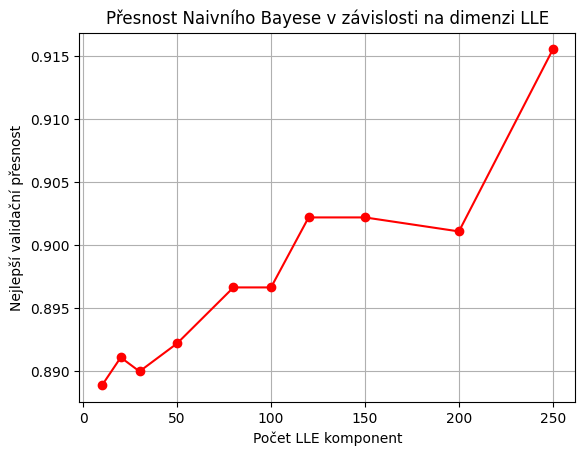


Nejlepší kombinace pro Naivního Bayese:
LLE počet komponent = 250
LLE počet sousedů = 10


In [22]:
best_score = 0
best_params = None
nb_scores = []

for n in lle_dims:
    best_score_for_n = 0
    best_neighbors_for_n = None
    
    for k in neighbors:
        try:
            pipeline = Pipeline([
                ('lle', LLE(n_components=n, n_neighbors=k, random_state=seed)),
                ('nb', GaussianNB())
            ])
            
            scores = cross_val_score(pipeline, Xtrain_scaled, ytrain, cv=3, scoring='accuracy', n_jobs=-1)
            mean_score = np.mean(scores)
            
            if mean_score > best_score_for_n:
                best_score_for_n = mean_score
                best_neighbors_for_n = k
                
            if mean_score > best_score:
                best_score = mean_score
                best_params = {'n_components': n, 'n_neighbors': k}
                
        except Exception as e:
            continue
    
    nb_scores.append(best_score_for_n)
    print(f"Nejlepší parametry pro LLE {n}: (neighbors={best_neighbors_for_n}), přesnost: {best_score_for_n:.4f}\n")

plt.plot(lle_dims, nb_scores, marker='o', color='red')
plt.xlabel("Počet LLE komponent")
plt.ylabel("Nejlepší validační přesnost")
plt.title("Přesnost Naivního Bayese v závislosti na dimenzi LLE")
plt.grid(True)
plt.show()

print("\nNejlepší kombinace pro Naivního Bayese:")
print(f"LLE počet komponent = {best_params['n_components']}")
print(f"LLE počet sousedů = {best_params['n_neighbors']}")

U Bayese je velmi značná změna v preferenci počtu dimenzí. S PCA se se zvyšující se dimenzí přesnost značně zhrošovala, ale u LLE je tomu naopak. Preferovaný počet komponent je o řád výš.

In [23]:
nb_lle_model = Pipeline([
    ('lle', LLE(n_components=best_params['n_components'],
                                   n_neighbors=best_params['n_neighbors'],
                                   random_state=seed)),
    ('nb', GaussianNB())
])

nb_lle_model.fit(Xtrain_scaled, ytrain)

ytrain_pred = nb_lle_model.predict(Xtrain_scaled)
print(f"Přesnost na trénovací sadě: {accuracy_score(ytrain, ytrain_pred):.4f}")
print(confusion_matrix(ytrain, ytrain_pred))

yval_pred = nb_lle_model.predict(Xval_scaled)
print(f"Přesnost na validační sadě: {accuracy_score(yval, yval_pred):.4f}")
print(confusion_matrix(yval, yval_pred))

model_accuracies['nb_lle_model'] = accuracy_score(yval, yval_pred)

Přesnost na trénovací sadě: 0.9078
[[376  67]
 [ 16 441]]
Přesnost na validační sadě: 0.8633
[[107  36]
 [  5 152]]


Celkově se ale nedá říct, že by se přesnost na validační množině zvlášť zlepšila v porovnání s modelem bez redukce dimenze, a je značně horší než model, který využívá PCA redukce. Model má rovněž stále problém s upřednostňováním jedné z tříd.

#### LDA

Nejlepší parametry pro LLE 10: {'lda__shrinkage': 'auto', 'lda__solver': 'lsqr', 'lle__n_neighbors': 20}, přesnost: 0.9189

Nejlepší parametry pro LLE 20: {'lda__shrinkage': None, 'lda__solver': 'svd', 'lle__n_neighbors': 15}, přesnost: 0.9389

Nejlepší parametry pro LLE 30: {'lda__shrinkage': None, 'lda__solver': 'svd', 'lle__n_neighbors': 15}, přesnost: 0.9400

Nejlepší parametry pro LLE 50: {'lda__shrinkage': None, 'lda__solver': 'svd', 'lle__n_neighbors': 15}, přesnost: 0.9489

Nejlepší parametry pro LLE 80: {'lda__shrinkage': None, 'lda__solver': 'svd', 'lle__n_neighbors': 15}, přesnost: 0.9500

Nejlepší parametry pro LLE 100: {'lda__shrinkage': None, 'lda__solver': 'svd', 'lle__n_neighbors': 20}, přesnost: 0.9489

Nejlepší parametry pro LLE 120: {'lda__shrinkage': None, 'lda__solver': 'svd', 'lle__n_neighbors': 20}, přesnost: 0.9456

Nejlepší parametry pro LLE 150: {'lda__shrinkage': None, 'lda__solver': 'svd', 'lle__n_neighbors': 15}, přesnost: 0.9456

Nejlepší parametry pro LLE

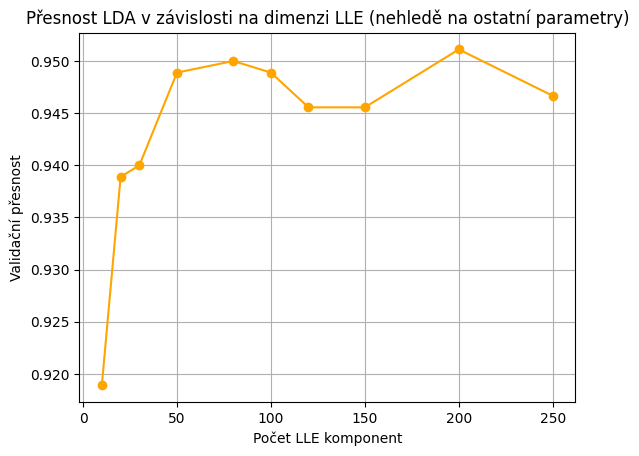


Celkově nejlepší kombinace:
LLE počet komponentů = 200
LLE + LDA parametry = {'lda__shrinkage': None, 'lda__solver': 'svd', 'lle__n_neighbors': 20}


In [24]:
param_grid = {
    'lle__n_neighbors': neighbors,
    'lda__solver': ['svd', 'lsqr', 'eigen'],
    'lda__shrinkage': [None, 'auto']
}

valid_grid = list(ParameterGrid(param_grid))

best_score = 0
best_params = None
best_n_components = None
lle_lda_scores = []

for n in lle_dims:
    best_score_for_n = 0
    best_params_for_n = None

    for params in valid_grid:
        try:
            lle = LLE(n_components=n, n_neighbors=params['lle__n_neighbors'], random_state=seed)
            lda = LDA(solver=params['lda__solver'], shrinkage=params['lda__shrinkage'])

            pipeline = Pipeline([
                ('lle', lle),
                ('lda', lda)
            ])

            scores = cross_val_score(pipeline, Xtrain_scaled, ytrain, cv=3, scoring='accuracy', n_jobs=-1)
            mean_score = scores.mean()

            if mean_score > best_score_for_n:
                best_score_for_n = mean_score
                best_params_for_n = params

            if mean_score > best_score:
                best_score = mean_score
                best_params = params
                best_n_components = n

        except Exception:
            pass

    lle_lda_scores.append(best_score_for_n)
    print(f"Nejlepší parametry pro LLE {n}: {best_params_for_n}, přesnost: {best_score_for_n:.4f}\n")

plt.plot(lle_dims, lle_lda_scores, marker='o', color='orange')
plt.xlabel("Počet LLE komponent")
plt.ylabel("Validační přesnost")
plt.title("Přesnost LDA v závislosti na dimenzi LLE (nehledě na ostatní parametry)")
plt.grid(True)
plt.show()

print("\nCelkově nejlepší kombinace:")
print(f"LLE počet komponentů = {best_n_components}")
print(f"LLE + LDA parametry = {best_params}")

Opět vidíme, že oproti PCA, LLE preferuje větší počet komponent. Preferovaný solver je stejný jako s PCA redukcí.

In [25]:
lda_lle_model = Pipeline([
    ('lle', LLE(n_components=best_n_components, n_neighbors=best_params['lle__n_neighbors'], random_state=seed)),
    ('lda', LDA(solver=best_params['lda__solver'], shrinkage=best_params['lda__shrinkage']))
])

lda_lle_model.fit(Xtrain_scaled, ytrain)

ytrain_pred = lda_lle_model.predict(Xtrain_scaled)
print(f"Přesnost na trénovací sadě: {accuracy_score(ytrain, ytrain_pred):.4f}")
print(confusion_matrix(ytrain, ytrain_pred))

yval_pred = lda_lle_model.predict(Xval_scaled)
print(f"Přesnost na validační sadě: {accuracy_score(yval, yval_pred):.4f}")
print(confusion_matrix(yval, yval_pred))

model_accuracies['lda_lle_model'] = accuracy_score(yval, yval_pred)

Přesnost na trénovací sadě: 0.9756
[[433  10]
 [ 12 445]]
Přesnost na validační sadě: 0.9400
[[132  11]
 [  7 150]]


Celková úspěšnost je podobná jako u LDA s PCA.

## Výsledky 🏆

Z celkem 9 různých kombinací modelů a redukce dimenze je nejúspěšnější, co se přesnosti týče, model SVM s PCA redukcí.

In [26]:
print(f"Dictionary size: {len(model_accuracies)} items")

best_key = max(model_accuracies, key=model_accuracies.get)
print(f"Best model: {best_key} (accuracy: {model_accuracies[best_key]:.4f})")

Dictionary size: 9 items
Best model: svm_pca_model (accuracy: 0.9600)


Na testovací množině, kterou jsem dosud nechali opomenutou, nyní můžeme zjistit očekávanou úspěšnost tohoto modelu na dosud neviděných datech:

In [27]:
ytest_pred = svm_pca_model.predict(Xtest_scaled)
print(f"Přesnost na testovaci sadě: {accuracy_score(ytest, ytest_pred):.4f}")
print(confusion_matrix(ytest, ytest_pred))

Přesnost na testovaci sadě: 0.9267
[[158  15]
 [  7 120]]


Nakonec už jen vytvoříme predikce pro evaluační data:

In [28]:
eval_data = pd.read_csv('evaluate.csv')
eval_ids = eval_data['ID']
Xeval = eval_data.drop('ID', axis=1)
Xeval_scaled = scaler.transform(Xeval)
predictions = svm_pca_model.predict(Xeval_scaled)

results = pd.DataFrame({
    'ID': eval_ids.values,
    'label': predictions
})

results.to_csv('results.csv', index=False)